In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

import torch
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, "../../src")

from juart.vis.interactive import InteractiveFigure3D, InteractiveMultiPlotter3D
from juart.vis.__init__ import MultiPlotter

In [2]:
device = "cpu"
normalize_images = True

# image0 = torch.load("../../../images/numOnion_ResNet_0i_100DC_10P_normalized/model_epoch_3").to(device).cpu().abs().numpy()[:,:,:,0,0]
# image1 = torch.load("../../../images/numOnion_ResNet_0i_100DC_10P_normalized/model_epoch_6").to(device).cpu().abs().numpy()[:,:,:,0,0]
# image2 = torch.load("../../../images/numOnion_ResNet_0i_100DC_10P_normalized/model_epoch_9").to(device).cpu().abs().numpy()[:,:,:,0,0]
# image3 = torch.load("../../../images/numOnion_ResNet_0i_100DC_10P_normalized/model_epoch_12").to(device).cpu().abs().numpy()[:,:,:,0,0]
# image4 = torch.load("../../../images/numOnion_ResNet_0i_100DC_10P_normalized/model_epoch_15").to(device).cpu().abs().numpy()[:,:,:,0,0]
# image5 = torch.load("../../../images/numOnion_ResNet_0i_100DC_10P_normalized/model_epoch_18").to(device).cpu().abs().numpy()[:,:,:,0,0]
# image6 = torch.load("../../../images/numOnion_ResNet_0i_100DC_10P_normalized/model_epoch_21").to(device).cpu().abs().numpy()[:,:,:,0,0]
# image7 = torch.load("../../../images/numOnion_ResNet_0i_100DC_10P_normalized/model_epoch_24").to(device).cpu().abs().numpy()[:,:,:,0,0]
# image8 = torch.load("../../../images/numOnion_ResNet_0i_100DC_10P_normalized/model_epoch_27").to(device).cpu().abs().numpy()[:,:,:,0,0]
# image9 = torch.load("../../../images/numOnion_ResNet_0i_100DC_10P_normalized/model_epoch_30").to(device).cpu().abs().numpy()[:,:,:,0,0]
# images_num = [image1,image3,image5,image7,image9]

# image10 = torch.load("../../../images/ResNet_0i_100DC_10P_1000spk_normalized/model_epoch_3").to(device).cpu().abs().numpy()[:,:,:,0,0]
# image11 = torch.load("../../../images/ResNet_0i_100DC_10P_1000spk_normalized/model_epoch_6").to(device).cpu().abs().numpy()[:,:,:,0,0]
# image12 = torch.load("../../../images/ResNet_0i_100DC_10P_1000spk_normalized/model_epoch_9").to(device).cpu().abs().numpy()[:,:,:,0,0]
# image13 = torch.load("../../../images/ResNet_0i_100DC_10P_1000spk_normalized/model_epoch_12").to(device).cpu().abs().numpy()[:,:,:,0,0]
# image14 = torch.load("../../../images/ResNet_0i_100DC_10P_1000spk_normalized/model_epoch_15").to(device).cpu().abs().numpy()[:,:,:,0,0]
# image15 = torch.load("../../../images/ResNet_0i_100DC_10P_1000spk_normalized/model_epoch_18").to(device).cpu().abs().numpy()[:,:,:,0,0]
# image16 = torch.load("../../../images/ResNet_0i_100DC_10P_1000spk_normalized/model_epoch_21").to(device).cpu().abs().numpy()[:,:,:,0,0]
# image17 = torch.load("../../../images/ResNet_0i_100DC_10P_1000spk_normalized/model_epoch_24").to(device).cpu().abs().numpy()[:,:,:,0,0]
# image18 = torch.load("../../../images/ResNet_0i_100DC_10P_1000spk_normalized/model_epoch_27").to(device).cpu().abs().numpy()[:,:,:,0,0]
# image19 = torch.load("../../../images/ResNet_0i_100DC_10P_1000spk_normalized/model_epoch_30").to(device).cpu().abs().numpy()[:,:,:,0,0]
# images_new_data = [image10,image12,image14,image16,image18]

# image20 = torch.load("../../../images/ResNet_01i_100DC_10P_1000spk_normalized/model_epoch_10").to(device).cpu().abs().numpy()[:,:,:,0,0]
# image21 = torch.load("../../../images/ResNet_01i_100DC_10P_1000spk_normalized/model_epoch_15").to(device).cpu().abs().numpy()[:,:,:,0,0]
# image22 = torch.load("../../../images/ResNet_01i_100DC_10P_1000spk_normalized/model_epoch_20").to(device).cpu().abs().numpy()[:,:,:,0,0]
# image23 = torch.load("../../../images/ResNet_01i_100DC_10P_1000spk_normalized/model_epoch_30").to(device).cpu().abs().numpy()[:,:,:,0,0]
# images_iloss = [image20,image21,image22,image23]

maxiters = [100,200,300,400,500]
num_of_resblocks = [2,4,6,8,10]
parameter_matrix = torch.zeros(size=(len(maxiters),len(num_of_resblocks),128,128,128,1,1))

for i,maxiter in enumerate(maxiters):

    for j,num in enumerate(num_of_resblocks):

        image = torch.load(f'../../../images/test_hyperparam/1U_{maxiter}DC_{num}RES')
        image /= image[20:100,20:100,65].cpu().abs().max()
        parameter_matrix[i][j] = image.cpu().abs()

parameter_matrix = parameter_matrix.flatten(0,1)
parameter_matrix = parameter_matrix.flatten(3,5)
parameter_matrix.shape

torch.Size([25, 128, 128, 128])

In [3]:
if normalize_images: pass
    # for image in images_num:
    #     image /= image[:,:,65].max()

    # for image in images_new_data:
    #     image /= image[:,:,65].max()

    # for image in images_iloss:
    #     image /= image[:,:,65].max()

In [8]:
print(image[:,:,60].abs().max())

tensor(1.5088, device='cuda:1')


interactive(children=(IntSlider(value=64, description='Dimension 3:', max=128, min=1), Output()), _dom_classes…

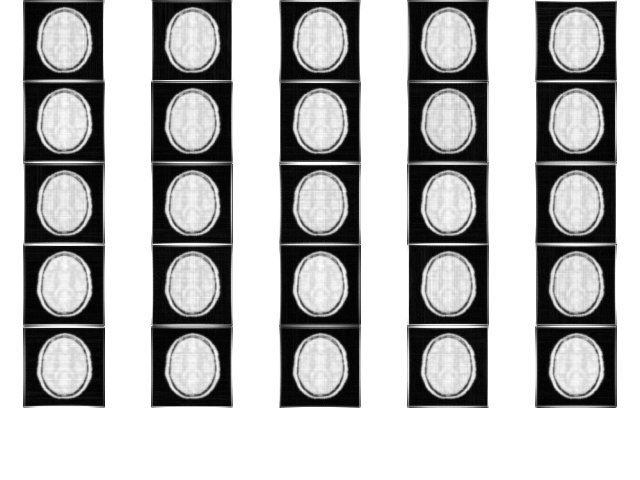

In [9]:
InteractiveMultiPlotter3D(parameter_matrix,
                          layout = [5,5],
                          title = None,
                          cmap="gray",
                          vmin = 0,
                          vmax = 1,
                          compact_plotting = True,
                          show_axis = False,
                          activate_colorbar = False).interactive